In [9]:
import numpy as np
import matplotlib.pyplot as plt
#import MiniPole code
#classes to create synthetic data, not needed if you have your data available
from mini_pole import GreenFunc
#from mini_pole.spectrum_example import *
###class to perform continuation
###from mini_pole import MiniPole
#class to perform real-frequency fitting
from mini_pole import MiniPoleRf
from scipy.interpolate import interp1d
from scipy.integrate import simpson
# Parche para compatibilidad con paquetes viejos en NumPy 2.x
if not hasattr(np, "complex_"):
    np.complex_ = np.complex128

In [10]:
def bethe_lattice_dos_indiv(x, t = 1.0):
    '''
    Intermediate function of bethe_lattice_dos(w, t) which only works for a single point.
    '''
    if np.abs(x) > 2 * t:
        return + 1e-9
    else:
        return 1.0 / (2.0 * np.pi * t**2.0) * np.sqrt(4 * t**2.0 - x**2.0) + 1e-9

def bethe_lattice_dos(w, t = 1.0):
    '''
    Density of states for the tight-binding model in Bethe lattice with interaction t.
    '''
    return np.vectorize(lambda x: bethe_lattice_dos_indiv(x, t))(w)

In [11]:

#### This function are used to MOLLIFY the function 
def bump_kernel(dw, eps, n_sigma=1.0):
    """
    Construye un kernel bump discreto, centrado en 0, de soporte ~[-eps, eps].
    dw      : spacing de la malla de frecuencia
    eps     : ancho del bump (en unidades de frecuencia)
    n_sigma : factor para decidir el tamaño del kernel en múltiplos de eps
    """
    # tamaño del kernel en puntos (lo hago un poco más grande que eps para seguridad)
    half_width = int(np.ceil(n_sigma * eps / dw))
    x = np.arange(-half_width, half_width + 1) * dw

    kernel = np.zeros_like(x, dtype=float)
    mask = np.abs(x) < eps
    y = x[mask] / eps
    kernel[mask] = np.exp(1.0 / (y**2 - 1.0))

    # normalizar para que int kernel dx ≈ 1
    norm = np.sum(kernel) * dw
    if norm > 0:
        kernel /= norm

    return kernel

def make_bethe_mollified_dos(t=1.0, eps_factor=0.1,
                             w_min_factor=10.0, w_max_factor=10.0,
                             n_w=4001):
    # Generates the grid with the desired number of points
    # and determine the equal spacing between the points 
    t = float(t)
    w_min = -w_min_factor * t
    w_max =  w_max_factor * t
    w_grid = np.linspace(w_min, w_max, n_w)
    dw = w_grid[1] - w_grid[0]
    # DOS Bethe original
    A_bethe = bethe_lattice_dos(w_grid, t=t)
    # mollifier
    eps = eps_factor * t
    kernel = bump_kernel(dw, eps)
    # convolución discreta
    A_moll = np.convolve(A_bethe, kernel, mode="same")
    # renormalizar el área con Simpson
    area = simpson(A_moll, w_grid)
    if area > 0:
        A_moll /= area
    A_moll_interp = interp1d(
        w_grid, A_moll,
        kind="linear",
        bounds_error=False,
        fill_value= 0.0#1e-9*0.5
    )
    return w_grid, A_bethe, A_moll, A_moll_interp


In [7]:
# construir DOS mollificada
w_grid, A_bethe, A_moll, A_moll_interp = make_bethe_mollified_dos(
    t=1.0, eps_factor=0.1, n_w=800001
)
y_bethe = [bethe_lattice_dos(wi) for wi in w_grid] ;

Object `simp` not found.


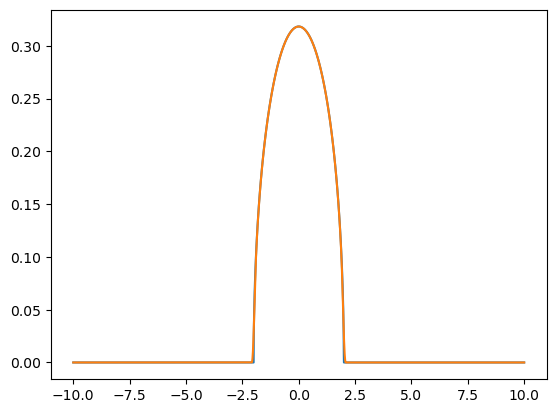

In [35]:
### Plot of interpolated method 
plt.plot(w_grid,y_bethe)
plt.plot(w_grid,A_moll_interp(w_grid))
plt.show()
#plt.ylim(-0.2e-8,0.2e-8)

In [78]:
#p1 = MiniPoleRf([bethe_lattice_dos], interval_type="infinite", wp_max=3, err=1.e-11, k_max=1000)
p = MiniPoleRf([A_moll_interp], interval_type="infinite", wp_max=3, err=1.e-11, k_max=2000)

/home/jalil2/.conda/envs/env/lib/python3.12/site-packages/mini_pole/mini_pole_rf.py:117: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return (0.5  / np.pi) * integrate.quad(lambda x: G_approx(self.con_map.w_max / np.tan(0.5 * x)), theta_min, theta_max, weight="cos", wvar=k + 1, complex_func=(self.func_type=="complex"), epsabs=tol, epsrel=tol, limit=10000)[0] + \


In [79]:
def cal_G_scalar(z, Al, xl):
    G_z = 0.0
    for i in range(xl.size):
        G_z += Al[i] / (z - xl[i])
    return G_z


In [103]:
idx2 = p.pole_location.imag < 0
print(p.pole_location.size)
print(idx2.size)
p.pole_weight[idx2] ; #.reshape(-1, 1))
p.pole_location[idx2] ; 

49
49


In [84]:
#p.change_M(50)
w = np.linspace(-6, 6, 200)
dos_r =  2 * cal_G_scalar( w, p.pole_weight, p.pole_location)#.real

In [116]:
R = p.pole_weight[:,0,0]
z = p.pole_location#.real

data_z = np.column_stack((z.real, z.imag))
data_R = np.column_stack((R.real, R.imag))

np.savetxt("z_Self.txt", data_z)
np.savetxt("R_Self.txt", data_R)

In [85]:
np.min(dos_r.real)

np.float64(9.761703405060797e-10)

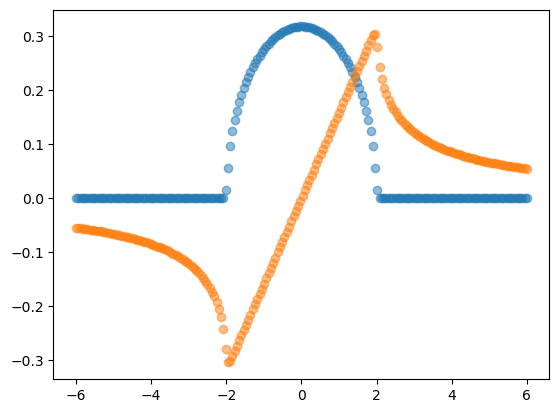

In [86]:
plt.scatter(w, dos_r.real,alpha=0.5 )
plt.scatter(w, dos_r.imag,alpha=0.5 )